# Assignment 2
## Part 2 - Evaluating time series

### 2A - Single series: seasonal cycle and trend

In [1]:
import matplotlib.pyplot as plt
import numpy as np

%load_ext autoreload
%autoreload 2

In [2]:
from amocatlas import read

transports = read.rapid()
trans_umo = transports.TRANS_UMO
moc = transports.MOC

Loading 1 RAPID 26°N dataset(s):
  0. moc_transports.nc: RAPID layer transport time series



In [3]:
transports

<xarray.Dataset> Size: 1MB
Dimensions:           (TIME: 14599)
Coordinates:
  * TIME              (TIME) datetime64[ns] 117kB 2004-04-02 ... 2024-03-27
Data variables:
    TRANS_0_800       (TIME) float64 117kB ...
    TRANS_800_1100    (TIME) float64 117kB ...
    TRANS_1100_3000   (TIME) float64 117kB ...
    TRANS_3000_5000   (TIME) float64 117kB ...
    TRANS_below_5000  (TIME) float64 117kB ...
    TRANS_FC          (TIME) float64 117kB ...
    TRANS_EKMAN       (TIME) float64 117kB ...
    TRANS_UMO         (TIME) float64 117kB ...
    MOC               (TIME) float64 117kB ...
Attributes: (12/37)
    title:                                 RAPID MOC timeseries
    summary:                               RAPID 26N transport estimates dataset
    description:                           RAPID 26N transport estimates dataset
    program:                               RAPID
    project:                               RAPID-AMOC 26°N array
    license:                               UK Open Government Licence v3.0 ht...
    ...                                    ...
    processing_software:                   http://github.com/AMOCcommunity/am...
    processing_version:                    0.4.0.post1.dev7
    processing_datasource:                 rapid26n
    product_version:                       2024.1a
    applied_variable_mapping:              {'time': 'TIME', 't_therm10': 'TRA...
    version:                               v2024.1a

In [4]:
# drop nans
moc_clean = moc.dropna(dim='TIME')
umo_clean = trans_umo.dropna(dim='TIME')

moc = moc_clean
trans_umo = umo_clean

#### Compute and remove the seasonal cycle — show the monthly climatology

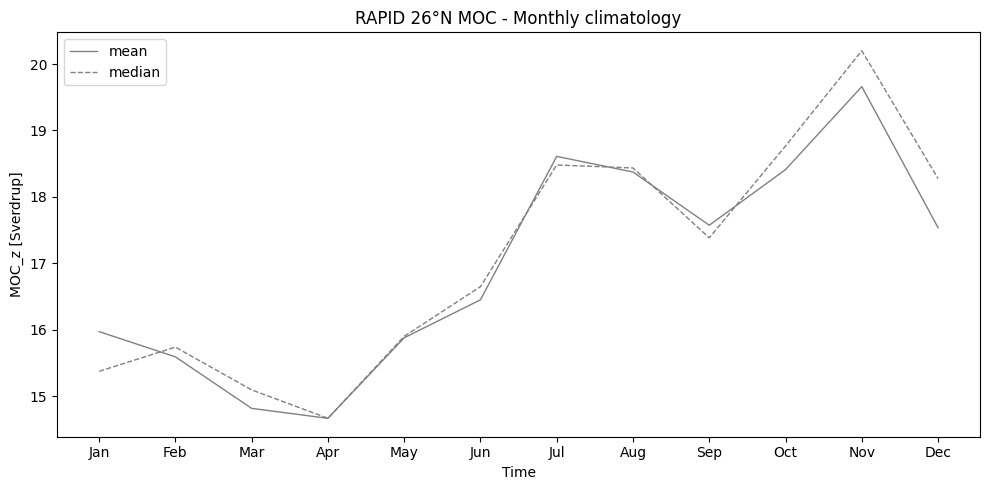

In [5]:
from amoc_analysis.spectra_filtering.analysis import seasonal_cycle

# Compute climatology
moc_clim = seasonal_cycle(moc.TIME, moc.values)
moc_clim.insert(0, 'month', ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# Plot monthly climatology
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(moc_clim['mean'], color="grey", ls='-', alpha=1, linewidth=1, label='mean')
ax.plot(moc_clim['median'], color="grey", ls='--', alpha=1, linewidth=1, label='median')

ax.set_title("RAPID 26°N MOC - Monthly climatology")
ax.set_ylabel('MOC_z [Sverdrup]')
ax.set_xlabel("Time")

ax.set_xticks(np.arange(1,13,1), labels=moc_clim['month'])

ax.legend()
plt.tight_layout()
fig.savefig('../plots/fig_2a_clim_moc', bbox_inches='tight')


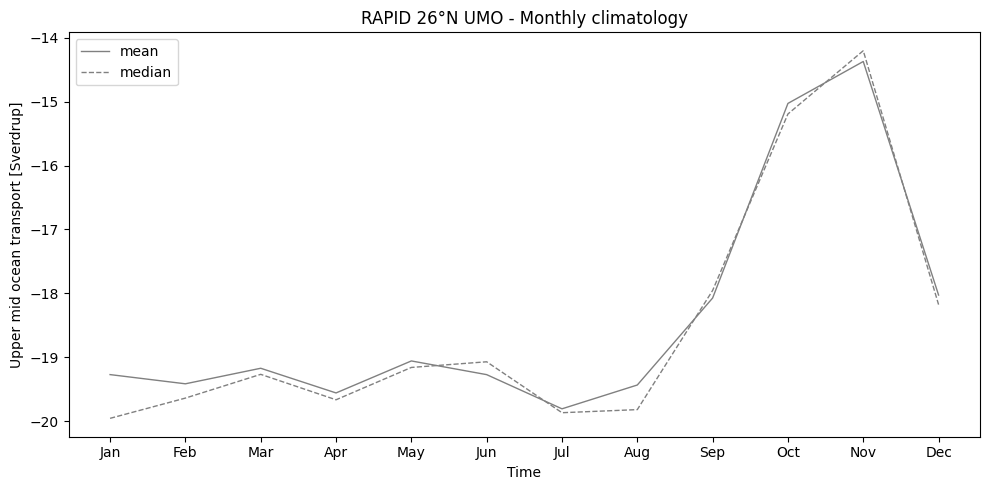

In [6]:
import matplotlib.pyplot as plt

from amoc_analysis.spectra_filtering.analysis import seasonal_cycle

# Compute seasonal cycle/climatology
trans_umo_clim = seasonal_cycle(trans_umo.TIME, trans_umo.values)
trans_umo_clim.insert(0, 'month', ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# Plot climatology
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(trans_umo_clim['mean'], color="grey", ls='-', alpha=1, linewidth=1, label='mean')
ax.plot(trans_umo_clim['median'], color="grey", ls='--', alpha=1, linewidth=1, label='median')

ax.set_title("RAPID 26°N UMO - Monthly climatology")
ax.set_ylabel('Upper mid ocean transport [Sverdrup]')
ax.set_xlabel("Time")

ax.set_xticks(np.arange(1,13,1), labels=trans_umo_clim['month'])

ax.legend()
fig.savefig('../plots/fig_2a_clim_umo', bbox_inches='tight')
plt.tight_layout()

#### Plot the deseasonalised series with the overall mean kept

(draw the deseasonalised line darker and thicker over the raw series)

In [7]:
import xarray as xr

# Map seasonal means to full time period -> make func
months = trans_umo.TIME.dt.month
clim_by_month = dict(zip(range(1, 13), trans_umo_clim['mean']))  # if clim is 12 values
trans_umo_clim_full = xr.DataArray(
    [clim_by_month[m] for m in months.values],
    dims="TIME", coords={"TIME": trans_umo.TIME}
)

# Map seasonal means to full time period -> make func
months = moc.TIME.dt.month
clim_by_month = dict(zip(range(1, 13), moc_clim['mean']))  # if clim is 12 values
moc_clim_full = xr.DataArray(
    [clim_by_month[m] for m in months.values],
    dims="TIME", coords={"TIME": moc.TIME}
)

trans_umo_deseasoned = trans_umo - trans_umo_clim_full
moc_deseasoned = moc - moc_clim_full

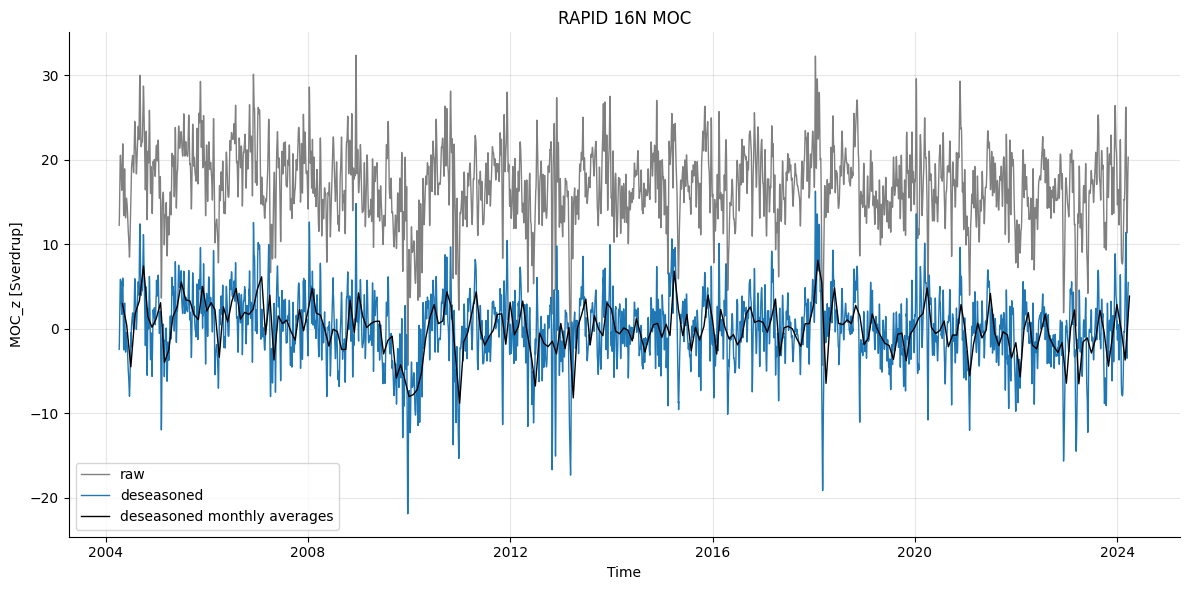

In [8]:
%autoreload
from amoc_analysis.plotting import plot_time_series_from_dataarray

# Deseasoned monthly averages
moc_monthly = moc_deseasoned.resample(TIME='ME').mean()

# Plot raw, deseasoned and deseasoned monthly averages
plot_time_series_from_dataarray([moc, moc_deseasoned, moc_monthly],
    title='RAPID 16N MOC',
    ylabel='MOC_z [Sverdrup]',
    labels=['raw', 'deseasoned', 'deseasoned monthly averages'],
    colors=['grey', 'tab:blue', 'k'],
    )
plt.savefig('../plots/fig_2a_moc_deseason.png', bbox_inches='tight')

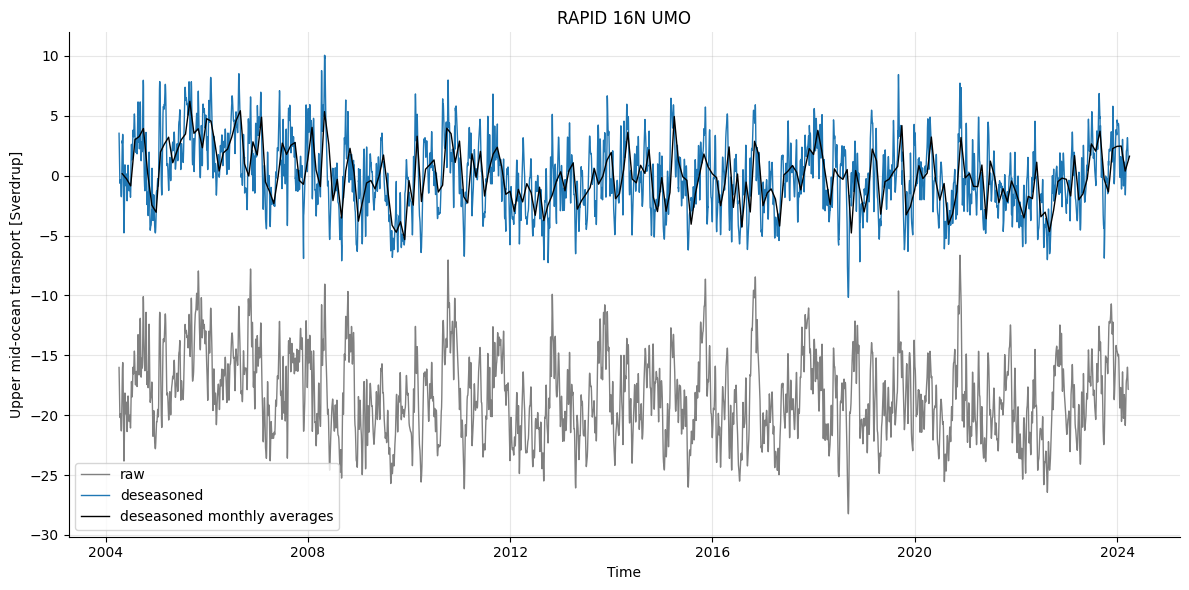

In [9]:
%autoreload
from amoc_analysis.plotting import plot_time_series_from_dataarray

# Deseasoned monthly averages
trans_umo_monthly = trans_umo_deseasoned.resample(TIME='ME').mean()

# Plot raw, deseasoned and deseasoned monthly averages
plot_time_series_from_dataarray([trans_umo, trans_umo_deseasoned, trans_umo_monthly],
    title='RAPID 16N UMO',
    ylabel='Upper mid-ocean transport [Sverdrup]',
    labels=['raw', 'deseasoned', 'deseasoned monthly averages'],
    colors=['grey', 'tab:blue', 'k'],
    )
plt.savefig('../plots/fig_2a_umo_deseason.png', bbox_inches='tight')

#### Show the autocorrelation with the decorrelation timescale $T^*$

- a line at $T^*$ is enough; shading optional
- $T^*$ sets the effective sample size

Notes
- autocorrelation $R(\tau)$: correlation between series and itself shifted by $\tau$ samples 

In [10]:
moc.TIME

<xarray.DataArray 'TIME' (TIME: 14579)> Size: 117kB
array(['2004-04-07T00:00:00.000000000', '2004-04-07T12:00:00.000000000',
       '2004-04-08T00:00:00.000000000', ..., '2024-03-21T00:00:00.000000000',
       '2024-03-21T12:00:00.000000000', '2024-03-22T00:00:00.000000000'],
      shape=(14579,), dtype='datetime64[ns]')
Coordinates:
  * TIME     (TIME) datetime64[ns] 117kB 2004-04-07 ... 2024-03-22
Attributes:
    long_name:      Time
    standard_name:  time
    calendar:       gregorian
    units:          seconds since 1970-01-01T00:00:00Z
    vocabulary:     http://vocab.nerc.ac.uk/collection/P01/current/ELTMEP01/

19.995422366567997 0.39701288991521333


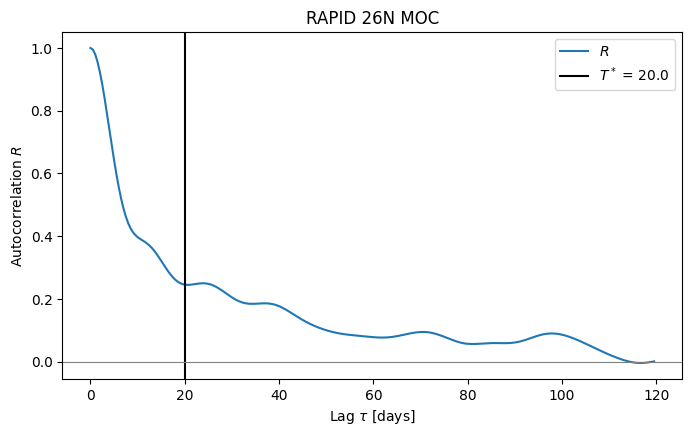

In [11]:
from amoc_analysis.correlation_trends.correlation import autocorr, integral_timescale

autocorr_moc = autocorr(x=moc)
dt = 0.5    # sampling time = 12 h = 0.5 days
T_moc = integral_timescale(x=moc, dt=dt)

n_show = 240
R = autocorr_moc[:n_show]
tau = np.arange(n_show) * dt

print(T_moc, R[round(T_moc)])

fig, ax = plt.subplots(figsize=(8, 4.5))

plt.plot(tau, R, label='$R$')
plt.axvline(x=T_moc, c='k', label=f'$T^*$ = {T_moc:.1f}')

plt.axhline(0, color="gray", lw=0.8)

plt.xlabel('Lag $\\tau$ [days]')
plt.ylabel('Autocorrelation $R$')

plt.legend()
plt.title('RAPID 26N MOC')

plt.savefig('../plots/fig_2a_moc_autocorr.png', bbox_inches='tight')

24.37934511350046 0.6084059747171592


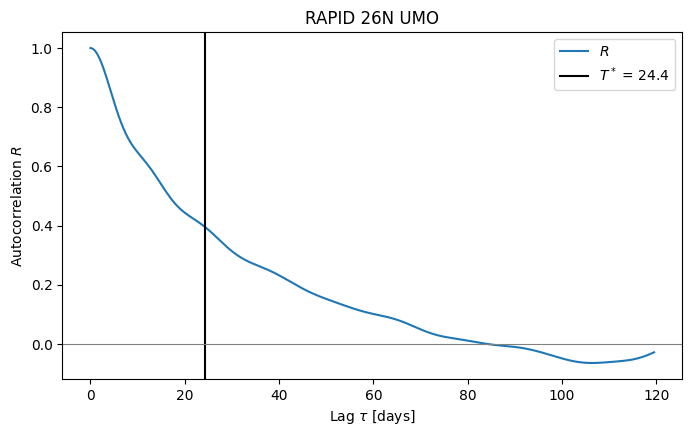

In [12]:
from amoc_analysis.correlation_trends.correlation import autocorr, integral_timescale

autocorr_umo = autocorr(x=trans_umo)
dt = 0.5    # sampling time = 12 h = 0.5 days
T_umo = integral_timescale(x=trans_umo, dt=dt)

n_show = 240
R = autocorr_umo[:n_show]
tau = np.arange(n_show) * dt

print(T_umo, R[round(T_umo)])

fig, ax = plt.subplots(figsize=(8, 4.5))

plt.plot(tau, R, label='$R$')
plt.axvline(x=T_umo, c='k', label=f'$T^*$ = {T_umo:.1f}')

plt.axhline(0, color="gray", lw=0.8)

plt.xlabel('Lag $\\tau$ [days]')
plt.ylabel('Autocorrelation $R$')

plt.legend()
plt.title('RAPID 26N UMO')

plt.savefig('../plots/fig_2a_umo_autocorr.png', bbox_inches='tight')

#### Fit a linear trend and test whether it differs from zero.

- compute linear trend
- report slope with standard error
- report slope in units of the standard error ($\sigma$ from 0)
- report p-value using effective sample size ($T^*$)
- state whether each trend is significant at 95% and why

In [13]:
moc

<xarray.DataArray 'MOC' (TIME: 14579)> Size: 117kB
array([12.223791, 12.450511, 12.741446, ..., 19.567366, 19.913258, 20.282887],
      shape=(14579,))
Coordinates:
  * TIME     (TIME) datetime64[ns] 117kB 2004-04-07 ... 2024-03-22
Attributes:
    long_name:      MOC_z
    units:          sverdrup
    description:    MOC strength
    standard_name:  ocean_meridional_overturning_streamfunction
    cell_methods:   DEPTH: maximum

In [14]:
# drop nans
moc_clean = moc.dropna(dim='TIME')
umo_clean = trans_umo.dropna(dim='TIME')
moc_clean.values

array([12.2237915 , 12.45051063, 12.74144551, ..., 19.56736559,
       19.91325843, 20.2828867 ], shape=(14579,))

In [15]:
%autoreload
from amoc_analysis.correlation_trends.trends import trend_with_significance

t_moc = np.arange(moc_clean.size, dtype=float) * dt
result_moc = trend_with_significance(t=t_moc, x=moc_clean.values, dt=dt)

t_umo = np.arange(umo_clean.size, dtype=float) * dt
result_umo = trend_with_significance(t=t_umo, x=umo_clean.values, dt=dt)

In [16]:
result_moc.printResult('MOC')

MOC
----------
slope    = -0.949 ± 0.540 Sv/decade
SE_naive = 0.063 Sv/decade
SE_eff   = 0.540 Sv/decade
slope/SE     = t_naive = -15.131 σ
slope/SE_eff = t_eff   = -1.758 σ
N_eff    = 197
p_naive  = 0.0000
p_eff    = 0.080
95% significance (|t_eff| > 1.96): False


In [17]:
result_umo.printResult('UMO')

UMO
----------
slope    = -1.063 ± 0.458 Sv/decade
SE_naive = 0.048 Sv/decade
SE_eff   = 0.458 Sv/decade
slope/SE     = t_naive = -22.015 σ
slope/SE_eff = t_eff   = -2.320 σ
N_eff    = 162
p_naive  = 0.0000
p_eff    = 0.022
95% significance (|t_eff| > 1.96): True


- similar trends: roughly -1 Sv/decade -> similar evidence for decline
- UMO significant at 95%, MOC is not (but close) (statistical view)
    - UMO has stronger (negative) slope (regular & in terms of effective SE) -> stronger signal than MOC
    - UMO has lower effective standard error -> less noise than MOC
- UMO has lower effective sample size -> stronger correlation?
- UMO has lower effective standard error
- naive tests are much larger (1 order of magnitude) than effective test (slope in units of effective SE) -> raw sample size would hugely overestimate significance